# Algoritmo Genético - Recriação de Imagem (Girl with a Pearl Earring)
Este notebook implementa a base (baseline) do Algoritmo Genético para recriar a imagem com 100 triângulos.

In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os

In [2]:
WIDTH = 300
HEIGHT = 400
NUM_TRIANGLES = 100

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## 1. Funções Base (Cromossoma e Renderização)

In [4]:
def load_target_image(filepath):
    """Loads the target image, resizes it and converts it from BGR to RGB."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Image {filepath} not found.")

    img = cv2.imread(filepath)

    if img is None:
        raise ValueError(f"Could not read image file: {filepath}")

    img = cv2.resize(img, (WIDTH, HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img


def get_local_color(target_img, cx, cy, patch_size=5):
    """
    Gets the average RGB color around a given pixel.
    """
    half = patch_size // 2

    x_min = max(0, cx - half)
    x_max = min(WIDTH, cx + half + 1)

    y_min = max(0, cy - half)
    y_max = min(HEIGHT, cy + half + 1)

    patch = target_img[y_min:y_max, x_min:x_max]

    color = np.mean(patch.reshape(-1, 3), axis=0)

    return tuple(color.astype(int))


def create_random_triangle(target_img=None):
    """
    Creates one random triangle.
    """
    cx = random.randint(0, WIDTH - 1)
    cy = random.randint(0, HEIGHT - 1)

    size = random.randint(10, 150)

    angles = np.sort(np.random.uniform(0, 2 * np.pi, 3))

    points = []

    for angle in angles:
        radius = random.randint(max(1, size // 3), size)

        x = int(cx + radius * np.cos(angle))
        y = int(cy + radius * np.sin(angle))

        x = int(np.clip(x, 0, WIDTH - 1))
        y = int(np.clip(y, 0, HEIGHT - 1))

        points.append((x, y))

    if target_img is not None:
        color = get_local_color(target_img, cx, cy)
    else:
        color = (
            random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255)
        )

    return {
        "p1": points[0],
        "p2": points[1],
        "p3": points[2],
        "color": color,
        "alpha": random.uniform(0.02, 0.80),
        "z": random.random()
    }


def create_random_individual(target_img=None):
    """Creates an individual composed of NUM_TRIANGLES triangles."""
    return [
        create_random_triangle(target_img)
        for _ in range(NUM_TRIANGLES)
    ]


def render_individual(individual, background_color=(0, 0, 0)):
    """
    Renders an individual into an RGB image.
    """
    canvas = np.full(
        (HEIGHT, WIDTH, 3),
        background_color,
        dtype=np.uint8
    )

    ordered_individual = sorted(
        individual,
        key=lambda tri: tri["z"]
    )

    for tri in ordered_individual:

        pts = np.array(
            [tri["p1"], tri["p2"], tri["p3"]],
            dtype=np.int32
        )

        mask = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

        cv2.fillPoly(mask, [pts], 255)

        color = np.array(tri["color"], dtype=np.float32)
        alpha = tri["alpha"]

        canvas_float = canvas.astype(np.float32)

        canvas_float[mask == 255] = (
            alpha * color +
            (1 - alpha) * canvas_float[mask == 255]
        )

        canvas = np.clip(
            canvas_float,
            0,
            255
        ).astype(np.uint8)

    return canvas

## 2. Operadores Genéticos e Fitness

In [5]:
def calculate_fitness(rendered, target):
    """
    Calculates RMSE between generated image and target image.
    """
    diff = rendered.astype(np.float32) - target.astype(np.float32)

    mse = np.mean(diff ** 2)

    return np.sqrt(mse)


def mutate(individual, target_img=None, mutation_rate=0.04):
    """
    Applies mutation to an individual.
    """
    new_individual = []

    for tri in individual:

        new_tri = tri.copy()

        step_pos = 5 if random.random() < 0.80 else 30
        step_col = 10 if random.random() < 0.80 else 60

        # Vertex mutation
        for point_key in ["p1", "p2", "p3"]:

            if random.random() < mutation_rate:

                x, y = new_tri[point_key]

                x = int(np.clip(
                    x + random.randint(-step_pos, step_pos),
                    0,
                    WIDTH - 1
                ))

                y = int(np.clip(
                    y + random.randint(-step_pos, step_pos),
                    0,
                    HEIGHT - 1
                ))

                new_tri[point_key] = (x, y)

        # Color mutation
        if random.random() < mutation_rate:

            r, g, b = new_tri["color"]

            r = int(np.clip(r + random.randint(-step_col, step_col), 0, 255))
            g = int(np.clip(g + random.randint(-step_col, step_col), 0, 255))
            b = int(np.clip(b + random.randint(-step_col, step_col), 0, 255))

            new_tri["color"] = (r, g, b)

        # Alpha mutation
        if random.random() < mutation_rate * 0.5:

            new_tri["alpha"] = float(np.clip(
                new_tri["alpha"] + random.uniform(-0.10, 0.10),
                0.02,
                0.80
            ))

        # Depth mutation
        if "z" in new_tri and random.random() < mutation_rate * 0.3:

            new_tri["z"] = float(np.clip(
                new_tri["z"] + random.uniform(-0.10, 0.10),
                0.0,
                1.0
            ))

        # Triangle shrinking
        if random.random() < mutation_rate * 0.4:

            cx = (
                new_tri["p1"][0] +
                new_tri["p2"][0] +
                new_tri["p3"][0]
            ) / 3

            cy = (
                new_tri["p1"][1] +
                new_tri["p2"][1] +
                new_tri["p3"][1]
            ) / 3

            for point_key in ["p1", "p2", "p3"]:

                x, y = new_tri[point_key]

                new_x = int(cx + (x - cx) * 0.8)
                new_y = int(cy + (y - cy) * 0.8)

                new_tri[point_key] = (
                    int(np.clip(new_x, 0, WIDTH - 1)),
                    int(np.clip(new_y, 0, HEIGHT - 1))
                )

        # Rare full replacement
        if random.random() < mutation_rate * 0.05:

            new_tri = create_random_triangle(target_img)

        new_individual.append(new_tri)

    return new_individual


def crossover(parent_1, parent_2):
    """
    Performs one-point crossover.
    """
    split = random.randint(1, NUM_TRIANGLES - 1)

    child = parent_1[:split] + parent_2[split:]

    return [triangle.copy() for triangle in child]

## 3. Ciclo Evolutivo

In [6]:
POP_SIZE = 60
GENERATIONS = 6000
MUTATION_RATE = 0.05
ELITE_SIZE = 6
TOURNAMENT_SIZE = 5

In [7]:
def tournament_selection(population, fitnesses, tournament_size=TOURNAMENT_SIZE):

    candidate_indices = random.sample(
        range(len(population)),
        tournament_size
    )

    best_index = min(
        candidate_indices,
        key=lambda idx: fitnesses[idx]
    )

    return population[best_index]


def evolve(
    target_img,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE,
    snapshot_generations=None,
    print_every=100
):

    print("Initializing population...")

    background_color = tuple(
        np.mean(target_img.reshape(-1, 3), axis=0).astype(int)
    )

    population = [
        create_random_individual(target_img)
        for _ in range(pop_size)
    ]

    best_fitness_history = []

    snapshots = {}

    if snapshot_generations is None:

        snapshot_generations = (
            list(range(0, generations, 500))
            + [generations - 1]
        )

    snapshot_generations = set(
        gen for gen in snapshot_generations
        if 0 <= gen < generations
    )

    best_individual = None

    for gen in range(generations):

        rendered_images = [
            render_individual(ind, background_color)
            for ind in population
        ]

        fitnesses = [
            calculate_fitness(rendered, target_img)
            for rendered in rendered_images
        ]

        sorted_indices = np.argsort(fitnesses)

        population = [population[i] for i in sorted_indices]
        fitnesses = [fitnesses[i] for i in sorted_indices]

        current_best_fit = fitnesses[0]

        best_individual = population[0]

        best_fitness_history.append(current_best_fit)

        if gen in snapshot_generations:

            best_rendered = render_individual(
                best_individual,
                background_color
            )

            snapshots[gen] = {
                "image": best_rendered.copy(),
                "rmse": current_best_fit
            }

        new_population = population[:elite_size]

        while len(new_population) < pop_size:

            parent_1 = tournament_selection(
                population,
                fitnesses,
                tournament_size
            )

            parent_2 = tournament_selection(
                population,
                fitnesses,
                tournament_size
            )

            child = crossover(parent_1, parent_2)

            child = mutate(
                child,
                target_img,
                mutation_rate
            )

            new_population.append(child)

        population = new_population

        if gen % print_every == 0 or gen == generations - 1:

            print(
                f"Generation {gen:05d} | "
                f"Best RMSE: {current_best_fit:.4f}"
            )

    return (
        best_individual,
        best_fitness_history,
        background_color,
        snapshots
    )

## 4. Teste e Visualização

Training in progress...
Initializing population...
Generation 00000 | Best RMSE: 55.0097
Generation 00100 | Best RMSE: 38.8362
Generation 00200 | Best RMSE: 33.8436
Generation 00300 | Best RMSE: 31.7356
Generation 00400 | Best RMSE: 30.5068
Generation 00500 | Best RMSE: 29.1842
Generation 00600 | Best RMSE: 28.5875
Generation 00700 | Best RMSE: 28.1730
Generation 00800 | Best RMSE: 27.9420
Generation 00900 | Best RMSE: 27.7811
Generation 01000 | Best RMSE: 27.4646
Generation 01100 | Best RMSE: 27.2917
Generation 01200 | Best RMSE: 27.0849
Generation 01300 | Best RMSE: 26.9775
Generation 01400 | Best RMSE: 26.9015
Generation 01500 | Best RMSE: 26.7590
Generation 01600 | Best RMSE: 26.6293
Generation 01700 | Best RMSE: 26.5870
Generation 01800 | Best RMSE: 26.4220
Generation 01900 | Best RMSE: 26.3018
Generation 02000 | Best RMSE: 26.2018
Generation 02100 | Best RMSE: 26.1556
Generation 02200 | Best RMSE: 26.0208
Generation 02300 | Best RMSE: 26.0097
Generation 02400 | Best RMSE: 25.9298

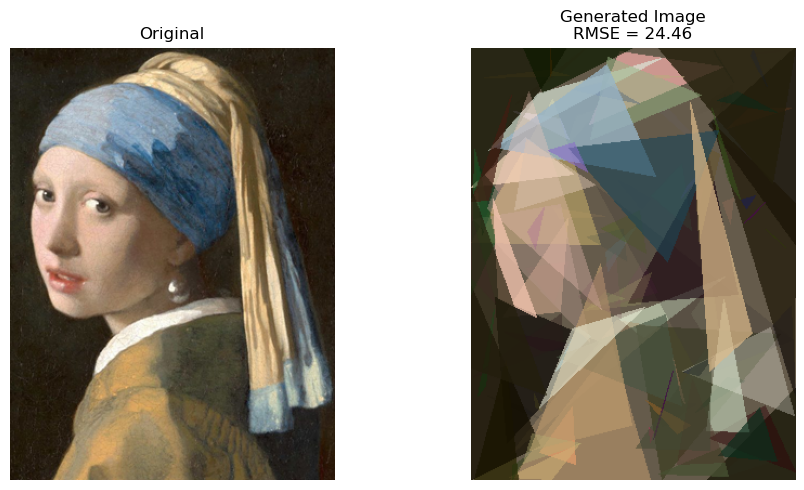

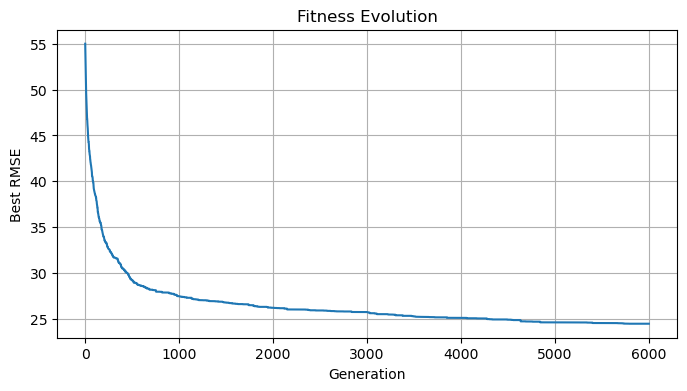

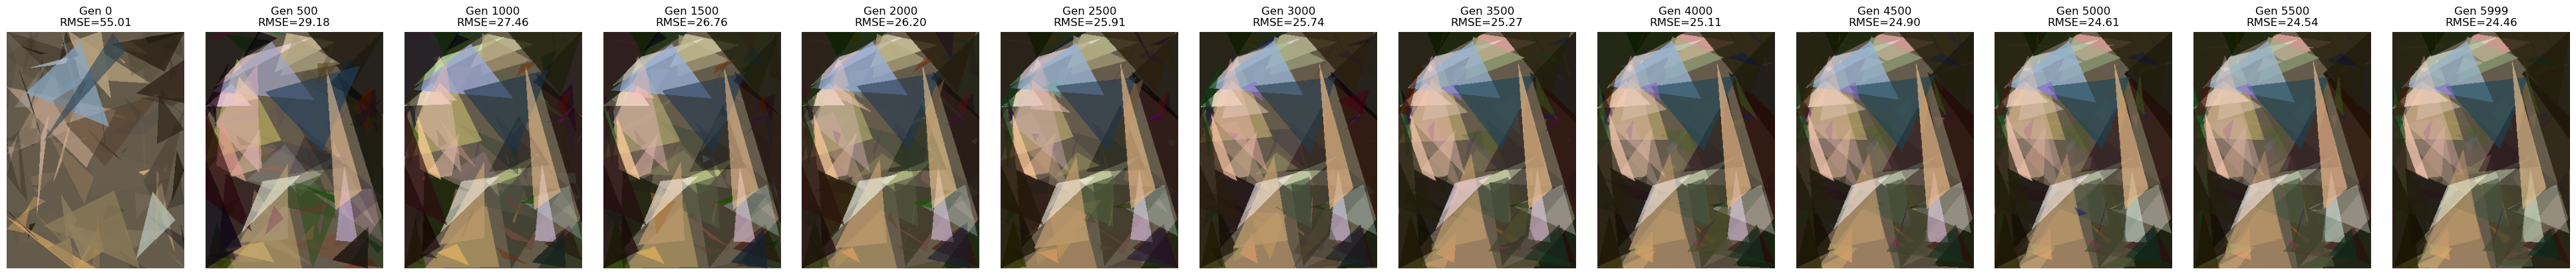

In [8]:
try:

    target = load_target_image("girl_pearl_earing.png")

    print("Training in progress...")

    best_ind, history, background_color, snapshots = evolve(
        target_img=target,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        mutation_rate=MUTATION_RATE,
        elite_size=ELITE_SIZE,
        tournament_size=TOURNAMENT_SIZE,
        snapshot_generations=(
            list(range(0, GENERATIONS, 500))
            + [GENERATIONS - 1]
        ),
        print_every=100
    )

    best_rend = render_individual(
        best_ind,
        background_color
    )

    final_rmse = calculate_fitness(
        best_rend,
        target
    )

    print(f"Final RMSE: {final_rmse:.4f}")

    # Original vs generated image
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    ax1.imshow(target)
    ax1.set_title("Original")
    ax1.axis("off")

    ax2.imshow(best_rend)
    ax2.set_title(
        f"Generated Image\nRMSE = {final_rmse:.2f}"
    )
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    # Fitness evolution
    plt.figure(figsize=(8, 4))

    plt.plot(history)

    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Best RMSE")

    plt.grid(True)

    plt.show()

    # Visual snapshots
    num_snapshots = len(snapshots)

    fig, axes = plt.subplots(
        1,
        num_snapshots,
        figsize=(3 * num_snapshots, 4)
    )

    if num_snapshots == 1:
        axes = [axes]

    for ax, (gen, data) in zip(axes, snapshots.items()):

        ax.imshow(data["image"])

        ax.set_title(
            f"Gen {gen}\nRMSE={data['rmse']:.2f}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.show()

except Exception as e:

    print("Error:", e)